<a href="https://colab.research.google.com/github/hetpatel1812/MachineLearning-Track/blob/main/Day_18/CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
from sklearn.preprocessing import LabelEncoder , StandardScaler
from sklearn.model_selection import train_test_split

from sklearn.linear_model import Perceptron    # Used for simple linear classification tasks.

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from tensorflow.keras.models import Sequential     # Sequential lets you build a neural network layer-by-layer in Keras.

from tensorflow.keras.layers import Dense     #Dense makes the final predictions
from tensorflow.keras.layers import Conv2D     # Conv2D extracts features
from tensorflow.keras.layers import Flatten    # Flatten reshapes them

from tensorflow.keras.layers import MaxPooling2D     # MaxPooling2D reduces size
from tensorflow.keras.layers import Dropout          # Dropout prevents overfitting

from tensorflow.keras.utils import to_categorical     # converts numeric class labels into one-hot encoded format for training classification models

In [3]:
df = pd.read_csv("/content/sample_data/mnist_train.csv")
df_test = pd.read_csv("/content/sample_data/mnist_test.csv")

In [4]:
df.head()

,label,1x1,1x2,1x3,1x4,1x5,1x6,1x7,1x8,1x9,...,28x19,28x20,28x21,28x22,28x23,28x24,28x25,28x26,28x27,28x28
0,5,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,4,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,9,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [5]:
df.columns

Index(['label', '1x1', '1x2', '1x3', '1x4', '1x5', '1x6', '1x7', '1x8', '1x9',
       ...
       '28x19', '28x20', '28x21', '28x22', '28x23', '28x24', '28x25', '28x26',
       '28x27', '28x28'],
      dtype='object', length=785)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5164 entries, 0 to 5163
Columns: 785 entries, label to 28x28
dtypes: float64(693), int64(92)
memory usage: 30.9 MB


In [8]:
df.isnull().sum()

,0
label,0
1x1,0
1x2,0
1x3,0
1x4,0
...,...
28x24,1
28x25,1
28x26,1
28x27,1


In [11]:
X_train = df.drop("label", axis=1).values
y_train = df["label"].values
X_test = df_test.iloc[:, 1:].values
y_test = df_test.iloc[:, 0].values

In [13]:
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

In [14]:
X_train_img = X_train.reshape(-1, 28, 28)
X_test_img = X_test.reshape(-1, 28, 28)

In [15]:
y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)

In [16]:
perceptron = Sequential([
    Flatten(input_shape=(28,28)),
    Dense(10, activation="softmax")
])

In [17]:
perceptron.compile(optimizer="sgd", loss="categorical_crossentropy", metrics=["accuracy"])

In [18]:
history_percp = perceptron.fit(X_train_img, y_train_cat, epochs=5, batch_size=32, validation_data=(X_test_img, y_test_cat), verbose=1)

Epoch 1/5
162/162 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - accuracy: 0.1146 - loss: nan - val_accuracy: 0.1009 - val_loss: nan
Epoch 2/5
162/162 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.0986 - loss: nan - val_accuracy: 0.1009 - val_loss: nan
Epoch 3/5
162/162 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.0986 - loss: nan - val_accuracy: 0.1009 - val_loss: nan
Epoch 4/5
162/162 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.0986 - loss: nan - val_accuracy: 0.1009 - val_loss: nan
Epoch 5/5
162/162 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.0986 - loss: nan - val_accuracy: 0.1009 - val_loss: nan


In [20]:
acc_percp = perceptron.evaluate(X_test_img, y_test_cat, verbose=0)[1]

In [21]:
acc_percp

0.10091008991003036

In [22]:
#ANN
ann = Sequential([
    Flatten(input_shape=(28,28)),
    Dense(128, activation="relu"),
    Dense(64, activation="relu"),
    Dense(10, activation="softmax")
])

In [23]:
ann.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])

In [24]:
history_ann = ann.fit(X_train_img, y_train_cat, epochs=5, batch_size=32, validation_data=(X_test_img, y_test_cat), verbose=1)

Epoch 1/5
162/162 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - accuracy: 0.1292 - loss: nan - val_accuracy: 0.1009 - val_loss: nan
Epoch 2/5
162/162 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.0986 - loss: nan - val_accuracy: 0.1009 - val_loss: nan
Epoch 3/5
162/162 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.0986 - loss: nan - val_accuracy: 0.1009 - val_loss: nan
Epoch 4/5
162/162 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.0986 - loss: nan - val_accuracy: 0.1009 - val_loss: nan
Epoch 5/5
162/162 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.0986 - loss: nan - val_accuracy: 0.1009 - val_loss: nan


In [25]:
acc_ann = ann.evaluate(X_test_img, y_test_cat, verbose=0)[1]

In [27]:
acc_ann

0.10091008991003036

In [28]:
X_train_cnn = X_train.reshape(-1, 28, 28,1)
X_test_cnn = X_test.reshape(-1, 28, 28, 1)

In [29]:
cnn = Sequential([
    Conv2D(32, kernel_size=(3,3), activation="relu", input_shape=(28,28,1)),
    MaxPooling2D(pool_size=(2,2)),
    Conv2D(64, kernel_size=(3,3), activation="relu"),
    MaxPooling2D(pool_size=(2,2)),
    Flatten(),
    Dense(128, activation="relu"),
    Dropout(0.5),
    Dense(10, activation="softmax")
])


In [30]:
cnn.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])

In [31]:
history_cnn = cnn.fit(X_train_cnn, y_train_cat, epochs=5, batch_size=32, validation_data=(X_test_cnn, y_test_cat), verbose=1)

Epoch 1/5
162/162 ━━━━━━━━━━━━━━━━━━━━ 10s 34ms/step - accuracy: 0.1050 - loss: nan - val_accuracy: 0.1009 - val_loss: nan
Epoch 2/5
162/162 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.0986 - loss: nan - val_accuracy: 0.1009 - val_loss: nan
Epoch 3/5
162/162 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.0986 - loss: nan - val_accuracy: 0.1009 - val_loss: nan
Epoch 4/5
162/162 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.0986 - loss: nan - val_accuracy: 0.1009 - val_loss: nan
Epoch 5/5
162/162 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.0986 - loss: nan - val_accuracy: 0.1009 - val_loss: nan


In [32]:
acc_cnn = cnn.evaluate(X_test_cnn, y_test_cat, verbose=0)[1]

In [33]:
acc_cnn

0.10091008991003036

In [34]:
def plot_training(history, title):
    plt.figure(figsize=(12,4))
    plt.subplot(1,2,1)
    plt.plot(history.history['accuracy'], label="Train")
    plt.plot(history.history['val_accuracy'], label="Val")
    plt.title(f"{title} Accuracy")
    plt.legend()

    plt.subplot(1,2,2)
    plt.plot(history.history['loss'], label="Train")
    plt.plot(history.history['val_loss'], label="Val")
    plt.title(f"{title} Loss")
    plt.legend()
    plt.show()

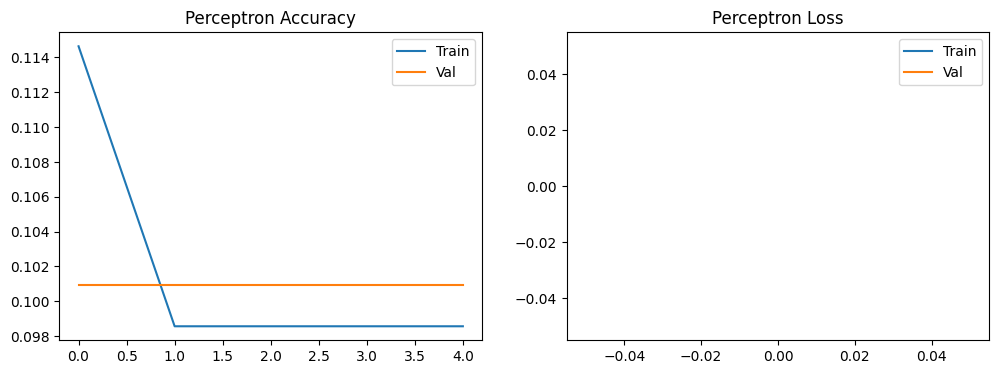

In [35]:
plot_training(history_percp, "Perceptron")

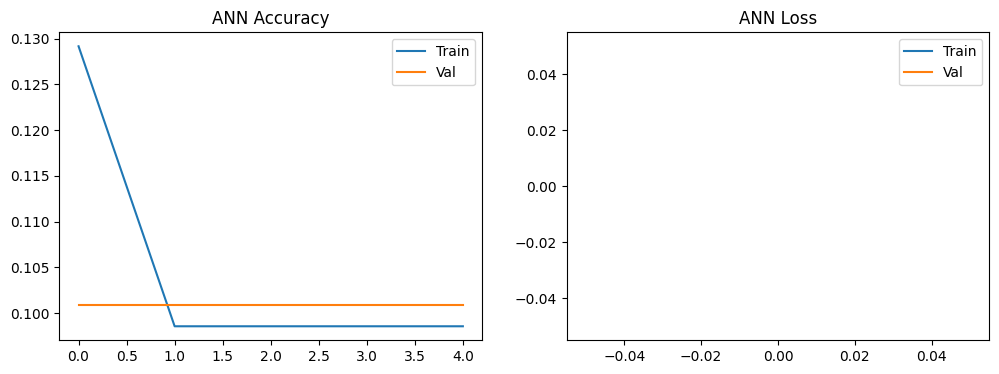

In [36]:
plot_training(history_ann, "ANN")

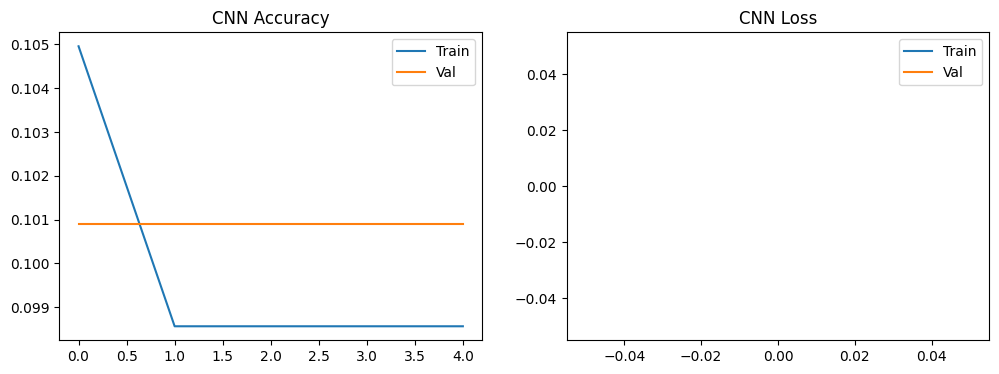

In [37]:
plot_training(history_cnn, "CNN")

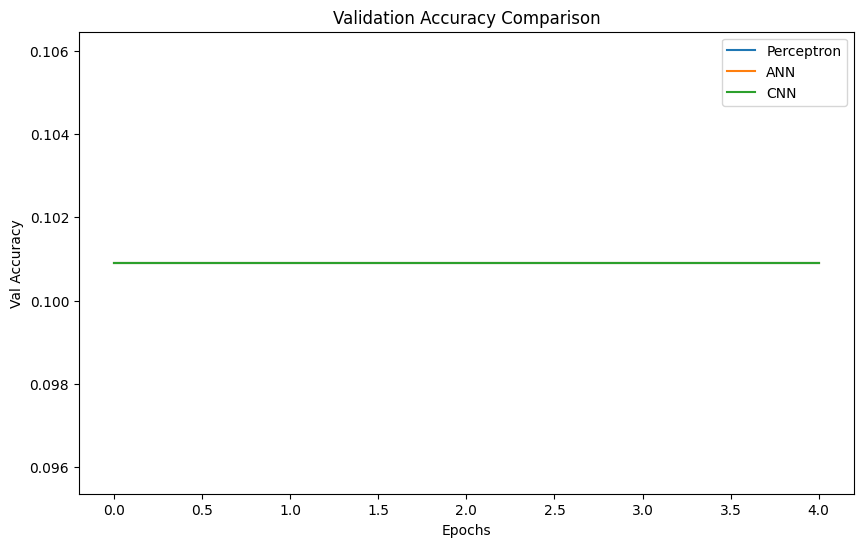

In [40]:
plt.figure(figsize=(10,6))
plt.plot(history_percp.history['val_accuracy'], label="Perceptron")
plt.plot(history_ann.history['val_accuracy'], label="ANN")
plt.plot(history_cnn.history['val_accuracy'], label="CNN")
plt.title("Validation Accuracy Comparison")
plt.xlabel("Epochs")
plt.ylabel("Val Accuracy")
plt.legend()
plt.show()

In [41]:
def show_side_by_side(models, model_names, X, X_cnn, y_true, n=5):
    idxs = np.random.choice(len(X), n, replace=False)
    plt.figure(figsize=(15, 6))
    for i, idx in enumerate(idxs):
        plt.subplot(2, n, i+1)
        plt.imshow(X[idx].reshape(28, 28), cmap="gray")
        plt.axis("off")
        plt.title(f"True: {y_true[idx]}")
        preds = [np.argmax(model.predict(X_cnn[idx].reshape(1, 28, 28, 1) if name == "CNN" else X[idx].reshape(1, 28, 28)))
                 for model, name in zip(models, model_names)]
        plt.subplot(2, n, n+i+1)
        plt.axis("off")
        plt.title("\n".join(f"{n}: {p}" for n, p in zip(model_names, preds)))
    plt.tight_layout()
    plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 235ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 490ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 722ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


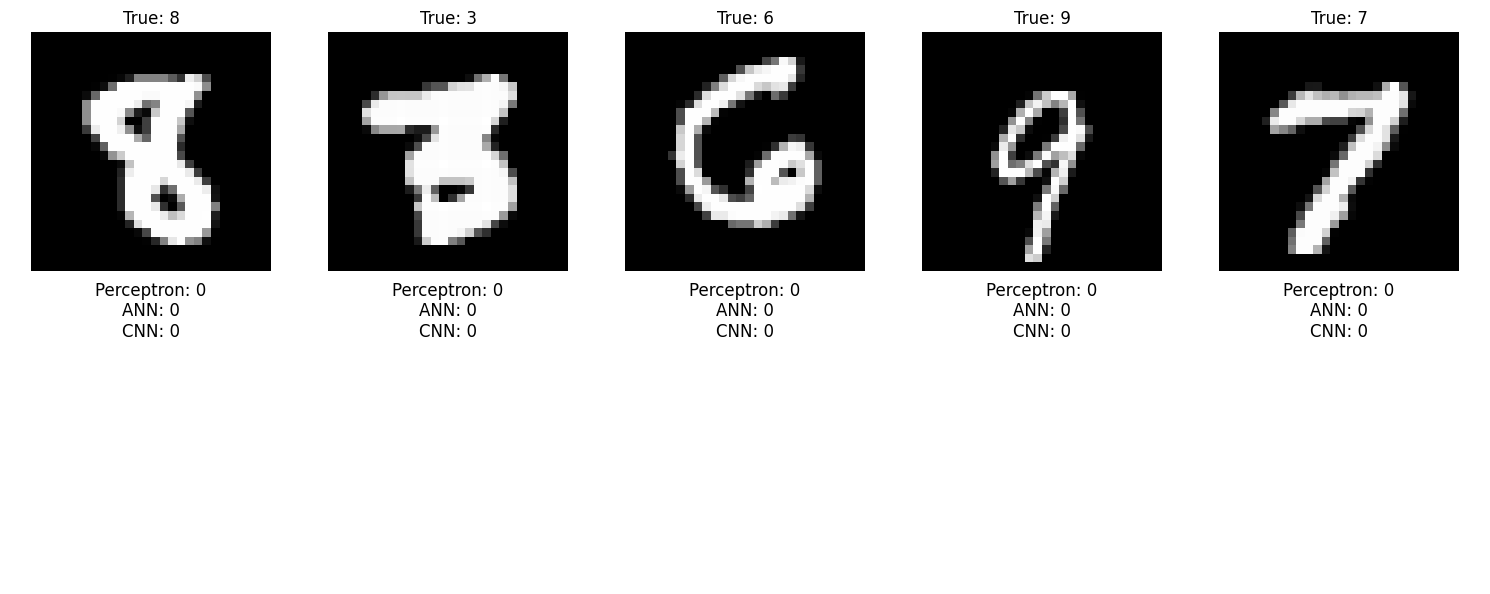

In [42]:
show_side_by_side([perceptron, ann, cnn], ["Perceptron", "ANN", "CNN"], X_test_img, X_test_cnn, y_test, 5)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step


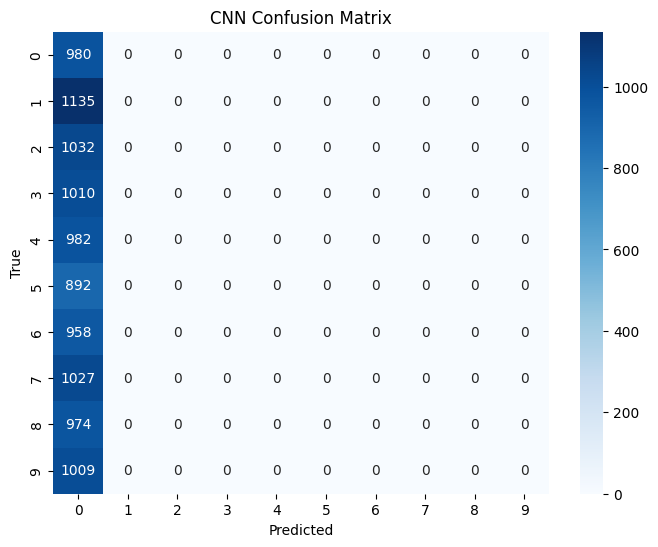

In [43]:

y_pred_cnn = np.argmax(cnn.predict(X_test_cnn), axis=1)
cm = confusion_matrix(y_test, y_pred_cnn)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("CNN Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()